## Zen of Python

In [1]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


## Introduction

Python ususally comes with two things
- Python Interpreter
- Support Library (with built in modules, classes and others)

## Interpreter and Compiler in Python

Python uses both compiler and interpreter, although the compilation of code is sort of 'hiddden', so people often called it as 'interpreted' langauge.

Python can works on various interpreters (or engine you can say) some of them are:

- **CPython** : this is a default interpreter in the Python, written in C(mostly)
- **Jython** : this interpreter is based on Java
- **PyPy** : use JIT(Just in Time) compiler to compile bytecode into machine code while the program is running, that makes it significantly faster

This is standard workflow of python interpreter:

![Python Interpreter](https://i.imgur.com/PJME67T.png)

If you look at it you'll notice that there are mainly two components of Python Interpreter
1) **Compiler** : 
This converts the source code into *byte code*, byte code is lower level platform indepandent code, python generates it as `.pyc` file and it stays in the memory till code execution after that it deletes it, if you want that file you can use modules like py_compile and compileall, there is one exeption though, if you import some modules `.pyc` file will generate automatically (so it can lavrage alrady compiled bytecode of module) and stays in the __pycatche__ folder.

2) **PVM (Python Virtual Machine)** : 
PVM takes the bytecode, interpret it line by line into a machine code.

In short the process will look like this:
1) Source Code (`.py`) → Compiler → Bytecode (`.pyc`)
2) Bytecode (`.pyc`) → Interpreter (PVM) → Machine Code (CPU)

## Deepdive into compilation by CPython

There is 3 phase involved in compilation by CPython
1. Lexer (Source Code -> Tokenizer -> Sequance of tokens)
2. Parser (Parser -> Abstract Syntex Tree)
3. Compiler (Symboic Table -> Byte Code Generation -> Code Object)

After which the PVM processes these steps in order to generate machine code
- Interpreter (Interpreter & Threads -> Frames -> Evaluation Loop)

### Lexer
It generates tokens from the given source code and provides it to the parser, note that in reality lexer and parser will be in the same building block, also note that rules of grammer are not defined in this step so it will generate tokens even if syntex error occurs in the code.

In [4]:
!python3 -m tokenize -e test.py

0,0-0,0:            ENCODING       'utf-8'        
1,0-1,3:            NAME           'num'          
1,4-1,5:            EQUAL          '='            
1,6-1,7:            NUMBER         '1'            
1,8-1,9:            PLUS           '+'            
1,10-1,11:          NUMBER         '2'            
1,11-1,12:          NEWLINE        '\n'           
2,0-2,2:            NAME           'if'           
2,3-2,6:            NAME           'num'          
2,7-2,8:            PERCENT        '%'            
2,9-2,10:           NUMBER         '2'            
2,11-2,13:          EQEQUAL        '=='           
2,14-2,15:          NUMBER         '0'            
2,15-2,16:          COLON          ':'            
2,16-2,17:          NEWLINE        '\n'           
3,0-3,4:            INDENT         '    '         
3,4-3,9:            NAME           'print'        
3,9-3,10:           LPAR           '('            
3,10-3,16:          STRING         '"even"'       
3,16-3,17:          RPAR       

### Parser

Parser will generate abstract syntex tree based on the grammer rules of the python langauge known as PEG (Python Expression Grammer) (you can check it out from [here](https://github.com/python/cpython/blob/3.14/Grammar/python.gram)) and with the help of actions in that grammer (Check it out [here](https://medium.com/@gvanrossum_83706/adding-actions-to-a-peg-grammar-d5e00fa1092f)).

In [1]:
from modules import test
import astpretty, ast, inspect

source = inspect.getsource(test)
astpretty.pprint(ast.parse(source), show_offsets=False)

odd
Module(
    body=[
        Assign(
            targets=[Name(id='num', ctx=Store())],
            value=BinOp(
                left=Constant(value=1, kind=None),
                op=Add(),
                right=Constant(value=2, kind=None),
            ),
            type_comment=None,
        ),
        If(
            test=Compare(
                left=BinOp(
                    left=Name(id='num', ctx=Load()),
                    op=Mod(),
                    right=Constant(value=2, kind=None),
                ),
                ops=[Eq()],
                comparators=[Constant(value=0, kind=None)],
            ),
            body=[
                Expr(
                    value=Call(
                        func=Name(id='print', ctx=Load()),
                        args=[Constant(value='even', kind=None)],
                        keywords=[],
                    ),
                ),
            ],
            orelse=[
                Expr(
                    value=Call(
     

### Compiler

Now after AST generation compiler will refer [operation codes](https://github.com/python/cpython/blob/main/Lib/opcode.py) and [symbol table](https://github.com/python/cpython/blob/main/Python/symtable.c) to generate the bytecode and after bytecode generation it filter out scope of variables using symbol table and handles control flow for generation of the code object.

In [24]:
compile('a + b',' ','eval').co_code

b'\x95\x00\\\x00\\\x01-\x00\x00\x00$\x00'

In [25]:
import dis
dis.dis('a + b')

  0           RESUME                   0

  1           LOAD_NAME                0 (a)
              LOAD_NAME                1 (b)
              BINARY_OP                0 (+)
              RETURN_VALUE


In [34]:
# symbol table lookup
import symtable
with open('test.py') as fp:
    st = symtable.symtable(fp.read(),'test.py','exec')
    s = st.lookup('num')
s.is_local()

True

In [37]:
#Control flow graph
from staticfg import CFGBuilder

with open('test.py') as fp:
    code = str(fp.read())

cfg = CFGBuilder().build_from_src('check_number', code)
cfg.build_visual('my_cfg', format='png')

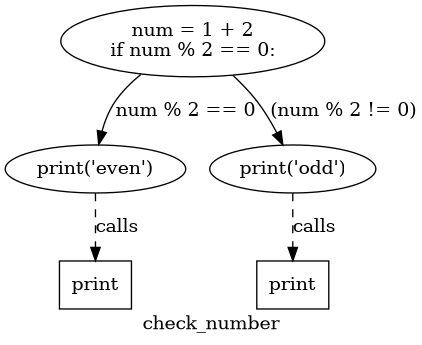

In [39]:
#Code object generation
with open('test.py') as fp:
    code_obj = compile(fp.read(),'<string>','exec')
for el in dir(code_obj):
    if not el.startswith('__'):
        print(f'{el} : {getattr(code_obj,el)}')

_co_code_adaptive : b'\x95\x00S\x00r\x00\\\x00S\x01-\x06\x11\x00S\x02:X\x11\x00a\tUU\\\x01"\x00S\x035\x01\x11\x00\x00\x00\x00\x00 \x00g\x05\\\x01"\x00S\x045\x01\x11\x00\x00\x00\x00\x00 \x00g\x05'
_varname_from_oparg : <built-in method _varname_from_oparg of code object at 0x7fe75450f000>
co_argcount : 0
co_cellvars : ()
co_code : b'\x95\x00S\x00r\x00\\\x00S\x01-\x06\x00\x00S\x02:X\x00\x00a\t\x00\x00\\\x01"\x00S\x035\x01\x00\x00\x00\x00\x00\x00 \x00g\x05\\\x01"\x00S\x045\x01\x00\x00\x00\x00\x00\x00 \x00g\x05'
co_consts : (3, 2, 0, 'even', 'odd', None)
co_exceptiontable : b''
co_filename : <string>
co_firstlineno : 1
co_flags : 0
co_freevars : ()
co_kwonlyargcount : 0
co_lines : <built-in method co_lines of code object at 0x7fe75450f000>
co_linetable : b'\xf0\x03\x01\x01\x01\xd8\x06\x0b\x80\x03\xd8\x03\x06\x88\x11\x817\x88a\x83<\xd9\x04\t\x88&\x85M\xe1\x04\t\x88%\x85L'
co_lnotab : b'\x00\xff\x02\x01\x04\x01\x12\x01\x12\x02'
co_name : <module>
co_names : ('num', 'print')
co_nlocals : 0
co

/tmp/ipykernel_19149/1326545350.py:6: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  print(f'{el} : {getattr(code_obj,el)}')


### Interpreter
interpreter go through the code object, and use [frame](https://github.com/python/cpython/blob/main/Include/internal/pycore_frame.h), if code object is blueprint than frame object provides enviorment for that blueprint, it also uses [evaluation loop](https://github.com/python/cpython/blob/main/Python/ceval.c) for final evaluation.

![alt:scalaton meme](https://i.imgflip.com/ai1h1e.jpg)